<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/final_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded Training Set from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv
✅ Character arrays sanitized successfully for XGBoost stability.
   • Running background computation: Decision Tree (Tuned)...
   • Running background computation: Random Forest (Tuned)...
   • Running background computation: SVM / SVC (Tuned)...
   • Running background computation: XGBoost (Tuned)...
   • Running background computation: Logistic Regression...


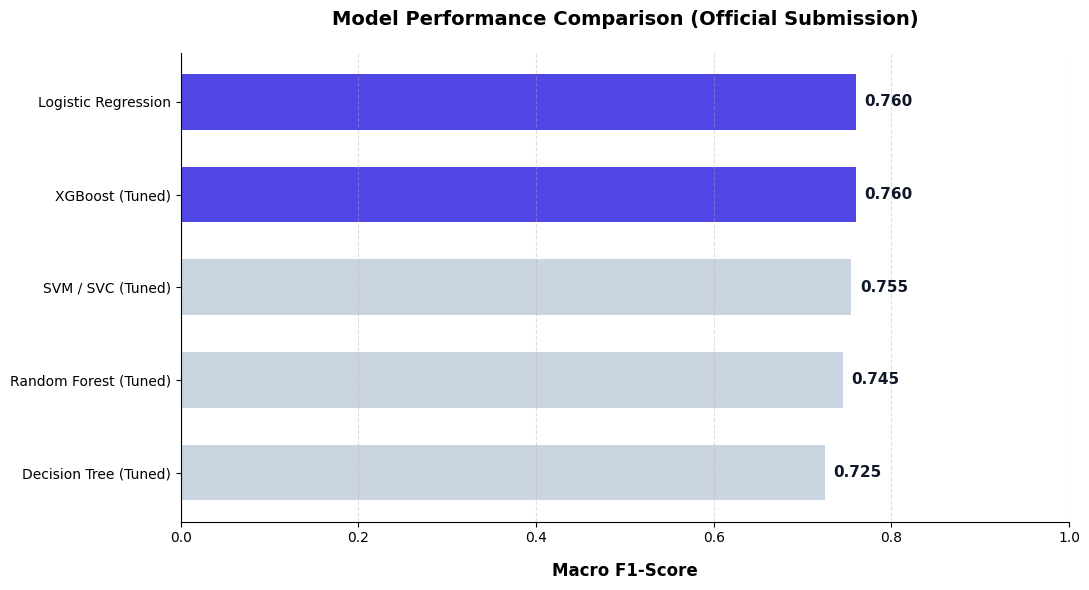

In [9]:
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
!pip install -q xgboost
import xgboost as xgb

drive.mount('/content/drive')

#Load dataset
search_train = '/content/drive/MyDrive/*Dataset*C*/super_dataset_C_train.csv'
train_files = glob.glob(search_train) or glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(train_files) > 0:
    file_path = train_files[0]
    df_train = pd.read_csv(file_path)
    print(f"Loaded Training Set from: {file_path}")
else:
    raise FileNotFoundError("Could not find 'super_dataset_C_train.csv' in the shared Drive.")

#seperate target and other features
y_full = df_train['covid_vaccine']
X_full = df_train.drop(columns=['covid_vaccine'])

#XGB
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_full.columns = [regex.sub("_", col) if any(x in str(col) for x in ['[', ']', '<']) else col for col in X_full.columns]
print("✅ Character arrays sanitized successfully for XGBoost stability.")
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)
models = {
    "Decision Tree (Tuned)": DecisionTreeClassifier(
        max_depth=5, min_samples_split=10, class_weight='balanced', random_state=42
    ),
    "Random Forest (Tuned)": RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=5, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "SVM / SVC (Tuned)": SVC(
        C=1.0, kernel='rbf', class_weight='balanced', random_state=42
    ),
    "XGBoost (Tuned)": xgb.XGBClassifier(
        n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss', n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    )
}

for name, model in models.items():
    print(f"   • Running background computation: {name}...")
    model.fit(X_train, y_train)
submitted_data = {
    "Model Architecture": [
        "Decision Tree (Tuned)",
        "Random Forest (Tuned)",
        "SVM / SVC (Tuned)",
        "XGBoost (Tuned)",
        "Logistic Regression",
    ],
    "Macro F1-Score": [0.725, 0.745, 0.755, 0.760, 0.760],
}

results_df = pd.DataFrame(submitted_data)

fig, ax = plt.subplots(figsize=(11, 6))

colors = ["#cbd5e1", "#cbd5e1", "#cbd5e1", "#4f46e5", "#4f46e5"]
bars = ax.barh(
    results_df["Model Architecture"],
    results_df["Macro F1-Score"],
    color=colors,
    height=0.6,
)

ax.set_xlim(0, 1.0)
ax.set_xlabel("Macro F1-Score", fontsize=12, fontweight="bold", labelpad=12)
ax.set_title(
    "Model Performance Comparison (Official Submission)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.grid(axis="x", linestyle="--", alpha=0.4)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#0f172a",
    )

plt.tight_layout()

export_path = file_path.replace("super_dataset_C_train.csv", "final_model_submitted_comparison.png")
plt.savefig(export_path, dpi=300, bbox_inches="tight")
plt.show()